### Exploratory Data Analysis

In [1]:
import pandas as pd
import ssl
import nltk

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alexandraflores/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/alexandraflores/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/alexandraflores/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/alexandraflores/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
# Install libraries not included in Colab by default
!pip install wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import FreqDist, pos_tag

# spaCy
import spacy
import subprocess, sys
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'], capture_output=True)
nlp = spacy.load('en_core_web_sm')

# WordCloud
from wordcloud import WordCloud

STOP_WORDS = set(stopwords.words('english'))
print("All libraries loaded.")

custom_stopwords = list({'movie', 'film','like','really','much','would','could','well','way','movies','films','one','good','make','even','made','also','get','think','see','many','go','know','better','character','characters','say','never','still','story','watched','watching','plot','acting','actor','got','much','way','thing','time','scenes','going','lot','though','scene','something','nothing','seen','almost','give','things','makes','enough','definitely','probably','always','another','actually','actors','end','every','two','first','watch','cast','actors','people','ever','want','instead','seem','role','play','cast','without','seeing','find','little','new','real','thought','big','quite','however','script','work','performance','ca','take','original','director','us','back','seems','may','bit','anything','show','completely','least','look','come','feel','done','keep','looking','making','although','goes','comedy','great','bad','right','part','best','fun','good','old','young','everything','life','job','saw','yet','great','screen','gets','year','especially','help','genre','bad','fan','right','excellent','expect','point','line','mind','man','come','look','problem','year','enjoyed','fact','best','pretty','day','one','two','three','years','found','sense','minutes','played','everyone','laught','enjoy','world','long','far','times','since','might','course','guy','throughout','together','girl','kind','moments','simply','audience','around','long','nice','hard','whole','trying','last','must','comedy','romance','action','comedies','drama','fantasy'})
STOP_WORDS = STOP_WORDS.union(custom_stopwords)

aspect_words = {'Speculative technology', 'dystopian', 'aliens', 'space travel', 'alternate realities', 'AI', 'cybernetic', 'Jump scares', 'suspense', 'dread', 'the macabre', 'final girl', 'supernatural', 'psychological tension', 'Conflict', 'emotional arc', 'realistic dialogue', 'societal issues', 'stakes', 'betrayal', 'redemption','Slapstick', 'timing', 'punchline', 'satire', 'mistaken identity', 'happy ending', 'wit', 'Stunts', 'explosions', 'car chases', 'hand-to-hand combat', 'hero\'s journey', 'ticking clock', 'villains','Meet-cute', 'chemistry', 'unrequited love', 'love triangle', 'grand gesture', 'soulmate', 'Mystery', 'plot twist', 'paranoia', 'cat-and-mouse', 'suspense', 'jeopardy', 'deception',"effects", "cgi", "graphics", "visualeffects", "animation", "stunts", "practical","emotional", "moving", "touching", "powerful", "tearjerker", "heartfelt", "poignant","atmosphere", "mood", "tense", "suspense", "suspenseful", "tension", "eerie", 
"unsettling", "dark", "lighthearted", "campy", 
"gripping", "compelling", "development, arc", "relatable", "likable", "unlikeable", 
"depth", "one-dimensional, nuanced","score", "soundtrack", "music", "sound", "song", "songs", "composer", "orchestration","pacing", "pace", "slow", "rushed", "dragged", "drags", "tight", "bloated", "lengthy", "brisk","funny", "humor", "humour", "comedic", "jokes", "hilarious", "witty", "satire", "satirical", 
"parody", "slapstick", "deadpan"}

You should consider upgrading via the '/Users/alexandraflores/venv/bin/.venv/bin/python3 -m pip install --upgrade pip' command.
All libraries loaded.


In [11]:
for word in aspect_words:
    count = df["clean_reviews"].str.contains(rf"\b{word}\b", case=False, na=False).sum()
    print(f"{word}: {count}")

NameError: name 'df' is not defined

### Load data


In [12]:
# Read the clean movie review CSV file

df = pd.read_csv("/Users/alexandraflores/Desktop/movie_reviews_clean_2000.csv", encoding="utf-8")
reviews = df['clean_reviews'].astype(str).tolist()

print(f"Rows loaded : {len(df)}")
print(f"Columns     : {list(df.columns)}")
df.head(10)


Rows loaded : 2000
Columns     : ['clean_movie_name', 'movie_name', 'movie_name_metadata', 'user_rating', 'movie_score', 'emotion', 'clean_reviews', 'clean_genre', 'clean_overview', 'clean_description', 'budget', 'revenue', 'budget_category', 'revenue_category', 'review_word_count', 'review_char_count', 'unique_word_count', 'average_word_length', 'positive_word_count', 'negative_word_count', 'simple_sentiment_score', 'keyword_text', 'overview_char_count', 'overview_word_count', 'description_char_count', 'description_word_count', 'genre_word_count', 'aspect_acting_performance_count', 'aspect_story_plot_count', 'aspect_characters_count', 'aspect_visuals_cinematography_count', 'aspect_sound_music_count', 'aspect_emotion_feeling_count', 'aspect_pace_length_count', 'aspect_genre_style_count', 'aspect_recommendation_count', 'aspect_quality_overall_count', 'tfidf_about', 'tfidf_acting', 'tfidf_after', 'tfidf_all', 'tfidf_also', 'tfidf_any', 'tfidf_bad', 'tfidf_because', 'tfidf_best', 'tfidf_b

,clean_movie_name,movie_name,movie_name_metadata,user_rating,movie_score,emotion,clean_reviews,clean_genre,clean_overview,clean_description,...,tfidf_say,tfidf_scenes,tfidf_see,tfidf_story,tfidf_think,tfidf_time,tfidf_two,tfidf_watch,tfidf_way,tfidf_well
0,the dictator,The Dictator,The Dictator,10.0,62.0,sadness,i wish there were more comedies like that - cr...,comedy,the heroic story of a dictator who risks his l...,"pursued by a cab driver for an unpaid fare, a ...",...,0.000000,0.0,0.206251,0.000000,0.000000,0.000000,0.0,0.253051,0.000000,0.211851
1,the assignment,The Assignment,The Assignment,3.0,55.0,anticipation,for a film that is strangely underwhelming and...,"action, crime, thriller",ace assassin frank kitchen is double crossed b...,obie (erica marks) is second-in-command in the...,...,0.177358,0.0,0.000000,0.134083,0.000000,0.139404,0.0,0.000000,0.000000,0.000000
2,big game,Big Game,Big Game,3.0,55.0,joy,comic book violence with gleaming visuals apar...,"action, adventure, thriller","air force one is shot down by terrorists, leav...","larry winthrop, the pampered son of an aristoc...",...,0.000000,0.0,0.000000,0.000000,0.000000,0.213408,0.0,0.000000,0.000000,0.214268
3,sixteen candles,Sixteen Candles,Sixteen Candles,7.0,68.0,sadness,"movies in the 80's were really cool, nice stor...","comedy, romance",a teenage girl deals with her parents forgetti...,"a girl's ""sweet"" sixteenth birthday is anythin...",...,0.000000,0.0,0.000000,0.078997,0.000000,0.082132,0.0,0.000000,0.095145,0.000000
4,the sorcerer's apprentice,The Sorcerer's Apprentice,The Sorcerer's Apprentice,8.0,61.0,fear,jay b. is funny and charming in a believably n...,"fantasy, adventure, action",balthazar blake is a master sorcerer in modern...,a young boy becomes an apprentice for a myster...,...,0.000000,0.0,0.181887,0.178973,0.000000,0.000000,0.0,0.000000,0.000000,0.186826
5,the twilight saga: breaking dawn - part 1,The Twilight Saga: Breaking Dawn - Part 1,The Twilight Saga: Breaking Dawn - Part 1,10.0,62.0,fear,this is my first review in imdb what i really ...,"adventure, fantasy, romance",the new found married bliss of bella swan and ...,the quileutes close in on expecting parents ed...,...,0.000000,0.0,0.000000,0.000000,0.311481,0.000000,0.0,0.000000,0.000000,0.000000
6,the heat,The Heat,Heat,4.0,79.0,sadness,this has been done so many times!the acting an...,"action, crime, drama, thriller",obsessive master thief neil mccauley leads a t...,"lola, a young playwright and drama director, g...",...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
7,the five-year engagement,The Five-Year Engagement,The Five-Year Engagement,5.0,58.0,sadness,"alas, this is another example of a movie with ...","comedy, romance","exactly one year after tom meets violet, he su...","one year after meeting, tom proposes to his gi...",...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
8,how to be single,How to Be Single,How to Be Single,10.0,62.0,joy,i think this movie was really genuine in the s...,"comedy, romance",new york city is full of lonely hearts seeking...,a group of young adults navigate love and rela...,...,0.000000,0.0,0.000000,0.288314,0.177427,0.000000,0.0,0.000000,0.173626,0.000000
9,rock of ages,Rock of Ages,Rock of Ages,9.0,62.0,sadness,my wife and i were both in high school during ...,"comedy, drama, music, romance",a small town girl and a city boy meet on the s...,a small-town girl and a city boy meet on the s...,...,0.000000,0.0,0.000000,0.214814,0.528782,0.000000,0.0,0.000000,0.000000,0.224240


### Pre-compute tokens and sentences

In [13]:
all_words = []   # list of word lists, one per document
all_sents = []   # list of sentence lists, one per document

for review in reviews:
    tokens = word_tokenize(review.lower())
    words  = [w for w in tokens if w.isalpha()]
    sents  = sent_tokenize(review)
    all_words.append(words)
    all_sents.append(sents)

print(f"Documents processed: {len(all_words)}")
print(f"Sample tokens (doc 0): {all_words[0][:10]}")

Documents processed: 2000
Sample tokens (doc 0): ['i', 'wish', 'there', 'were', 'more', 'comedies', 'like', 'that', 'crossing', 'over']


### CORPUS OVERVIEW

In [14]:
#Finding the number of documents, total words, and total characters in the dataset
n_docs = len(reviews)

# Flatten all words into one list
flat_words = []
for word_list in all_words:
    for word in word_list:
        flat_words.append(word)

total_words = len(flat_words)
total_chars = sum(len(review) for review in reviews)

print(f"Number of documents : {n_docs:,}")
print(f"Total words         : {total_words:,}")
print(f"Total characters    : {total_chars:,}")

Number of documents : 2,000
Total words         : 490,015
Total characters    : 2,829,301


### Document length

In [15]:

word_counts = []
for word_list in all_words:
    word_counts.append(len(word_list))

avg_length = sum(word_counts) / len(word_counts)

print(f"Average document length : {avg_length:.1f} words")
print(f"Shortest document       : {min(word_counts)} words")
print(f"Longest document        : {max(word_counts)} words")

Average document length : 245.0 words
Shortest document       : 10 words
Longest document        : 1026 words


### Vocab and lexical diversity 

In [16]:
vocab = set(flat_words)
vocab_size = len(vocab)
lexical_div = vocab_size / total_words

print(f"Vocabulary size   : {vocab_size:,} unique words")
print(f"Lexical diversity : {lexical_div:.4f}")

Vocabulary size   : 22,315 unique words
Lexical diversity : 0.0455


### Text Structure Statistics

In [17]:
char_counts = []
for review in reviews:
    char_counts.append(len(review))

sent_counts = []
for sent_list in all_sents:
    sent_counts.append(len(sent_list))

print("Word counts  — mean:", round(np.mean(word_counts), 1),
      " median:", round(np.median(word_counts), 1))
print("Char counts  — mean:", round(np.mean(char_counts), 1),
      " median:", round(np.median(char_counts), 1))
print("Sent counts  — mean:", round(np.mean(sent_counts), 1),
      " median:", round(np.median(sent_counts), 1))

Word counts  — mean: 245.0  median: 180.0
Char counts  — mean: 1414.7  median: 1008.0
Sent counts  — mean: 11.6  median: 10.0


### Average Words Per Sentence

In [18]:
avg_wps = []   # average words per sentence, one value per document
for i in range(len(reviews)):
    if sent_counts[i] == 0:
        avg_wps.append(0)
    else:
        avg_wps.append(word_counts[i] / sent_counts[i])

print(f"Average words per sentence (corpus mean): {np.mean(avg_wps):.1f}")

Average words per sentence (corpus mean): 24.9


### Summary Table

In [19]:
summary = pd.DataFrame({
    'Metric'  : ['Word Count', 'Char Count', 'Sentence Count', 'Avg Words/Sent'],
    'Mean'    : [np.mean(word_counts), np.mean(char_counts),
                 np.mean(sent_counts), np.mean(avg_wps)],
    'Median'  : [np.median(word_counts), np.median(char_counts),
                 np.median(sent_counts), np.median(avg_wps)],
    'Std Dev' : [np.std(word_counts), np.std(char_counts),
                 np.std(sent_counts), np.std(avg_wps)],
    'Min'     : [min(word_counts), min(char_counts),
                 min(sent_counts), min(avg_wps)],
    'Max'     : [max(word_counts), max(char_counts),
                 max(sent_counts), max(avg_wps)],
})
summary = summary.round(2)
summary

,Metric,Mean,Median,Std Dev,Min,Max
0,Word Count,245.01,180.00,183.08,10.0,1026.0
1,Char Count,1414.65,1008.00,1077.19,53.0,6193.0
2,Sentence Count,11.64,10.00,8.19,1.0,66.0
3,Avg Words/Sent,24.94,20.13,25.75,5.0,507.0


### Length Distribution

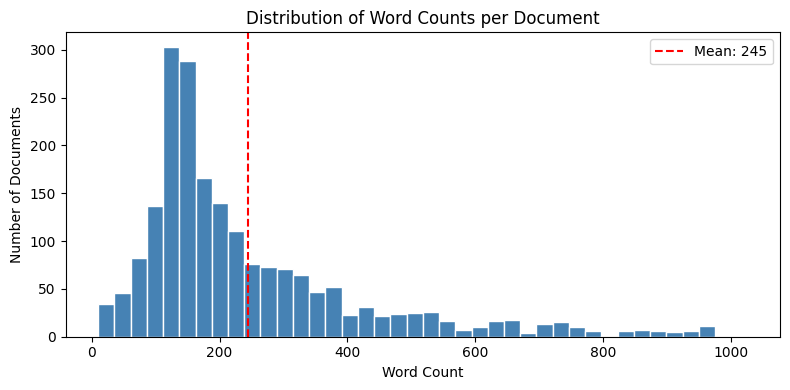

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(word_counts, bins=40, color='steelblue', edgecolor='white')
plt.axvline(np.mean(word_counts), color='red', linestyle='--',
            label=f"Mean: {np.mean(word_counts):.0f}")
plt.title('Distribution of Word Counts per Document')
plt.xlabel('Word Count')
plt.ylabel('Number of Documents')
plt.legend()
plt.tight_layout()
plt.show()

###  Histogram of Character Counts

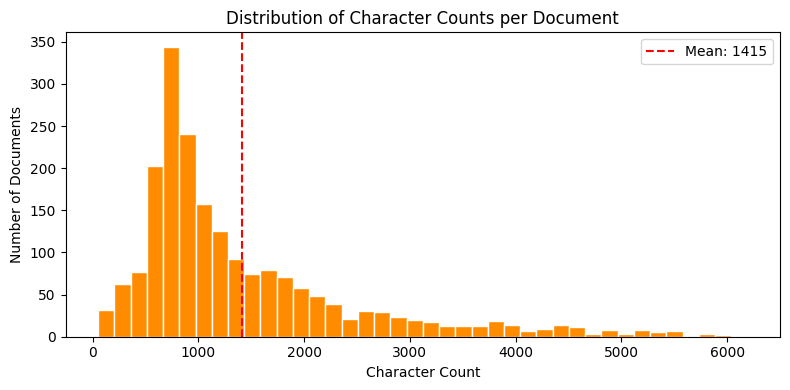

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(char_counts, bins=40, color='darkorange', edgecolor='white')
plt.axvline(np.mean(char_counts), color='red', linestyle='--',
            label=f"Mean: {np.mean(char_counts):.0f}")
plt.title('Distribution of Character Counts per Document')
plt.xlabel('Character Count')
plt.ylabel('Number of Documents')
plt.legend()
plt.tight_layout()
plt.show()

### Histogram of Sentence Counts

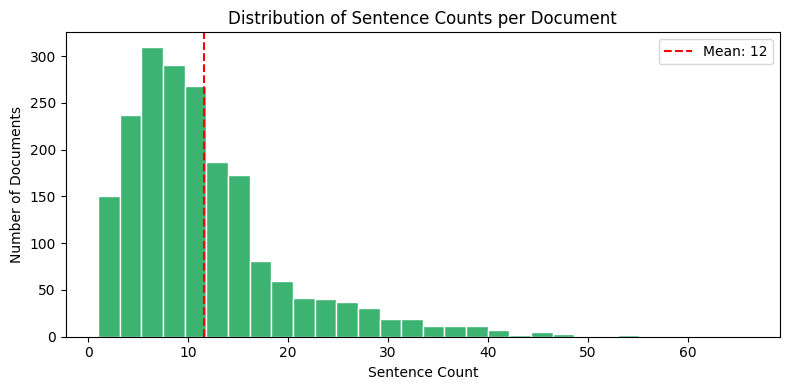

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(sent_counts, bins=30, color='mediumseagreen', edgecolor='white')
plt.axvline(np.mean(sent_counts), color='red', linestyle='--',
            label=f"Mean: {np.mean(sent_counts):.0f}")
plt.title('Distribution of Sentence Counts per Document')
plt.xlabel('Sentence Count')
plt.ylabel('Number of Documents')
plt.legend()
plt.tight_layout()
plt.show()

###  Identify Short and Long Reviews

In [23]:
p10 = np.percentile(word_counts, 10)
p90 = np.percentile(word_counts, 90)

short_reviews = []
long_reviews  = []

for i in range(len(reviews)):
    if word_counts[i] <= p10:
        short_reviews.append(i)
    elif word_counts[i] >= p90:
        long_reviews.append(i)

print(f"10th percentile : {p10:.0f} words  ->  {len(short_reviews)} short reviews")
print(f"90th percentile : {p90:.0f} words  ->  {len(long_reviews)} long reviews")

print("\n--- Sample SHORT review ---")
print(reviews[short_reviews[0]][:300])

print("\n--- Sample LONG review ---")
print(reviews[long_reviews[0]][:300])

10th percentile : 97 words  ->  206 short reviews
90th percentile : 504 words  ->  201 long reviews

--- Sample SHORT review ---
this has been done so many times!the acting and effects were diabolical, really poor.slow and dragged out, not the usual amazing stories level of quality viewing.

--- Sample LONG review ---
when we imagine a post-apocalyptic world, it usually includes a lot of broken down buildings, stray dogs and a bunch of raggedy and tough survivors, but rarely zombies! warm bodies, rated pg-13, is a hilarious look at what could be, a world in which humans are uncommon and zombies roam the land look


### Word Frequency Analysis

### Top Words with Stopwords

In [24]:
# Count every word in the corpus
freq_all = Counter(flat_words)

top_all = freq_all.most_common(20)
print("Top 20 words (including stopwords):")
for word, count in top_all:
    print(f"  {word:<20} {count}")

Top 20 words (including stopwords):
  the                  27150
  and                  15288
  a                    14236
  of                   11944
  to                   11825
  is                   9833
  it                   8829
  i                    8016
  in                   7445
  that                 6464
  this                 6052
  movie                4615
  was                  4254
  with                 4183
  as                   4087
  but                  3996
  for                  3900
  film                 3592
  you                  3584
  not                  3069


### Top content words (stopwords removed)

In [25]:
flat_content = []
for word in flat_words:
    if word not in STOP_WORDS:
        flat_content.append(word)

freq_content = Counter(flat_content)

top_content_words = freq_content.most_common(20)
print("Top 20 content words (no stopwords):")
for word, count in top_content_words:
    print(f"  {word:<20} {count}")

Top 20 content words (no stopwords):
  love                 951
  funny                505
  family               284
  book                 282
  romantic             282
  interesting          280
  music                279
  beautiful            249
  sure                 242
  sex                  235
  kids                 231
  believe              230
  different            226
  worth                226
  main                 223
  let                  222
  away                 222
  perfect              222
  woman                221
  friends              219


Top words vs content words

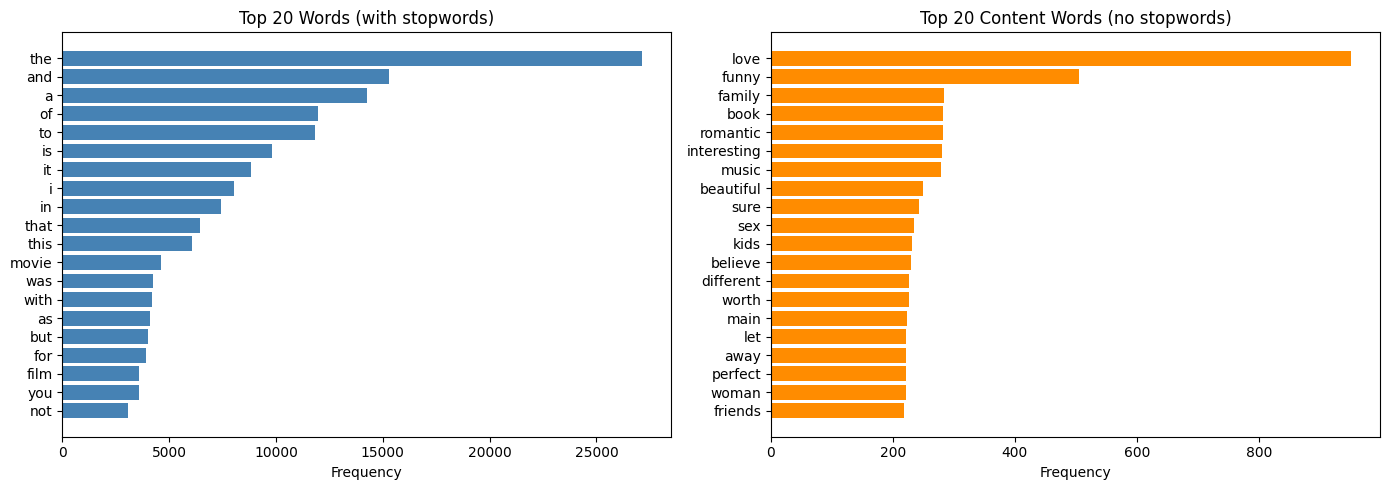

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all words
words_all, counts_all = zip(*top_all)
axes[0].barh(list(reversed(words_all)), list(reversed(counts_all)), color='steelblue')
axes[0].set_title('Top 20 Words (with stopwords)')
axes[0].set_xlabel('Frequency')

# Right: content words
words_c, counts_c = zip(*top_content_words)
axes[1].barh(list(reversed(words_c)), list(reversed(counts_c)), color='darkorange')
axes[1].set_title('Top 20 Content Words (no stopwords)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### Word cloud

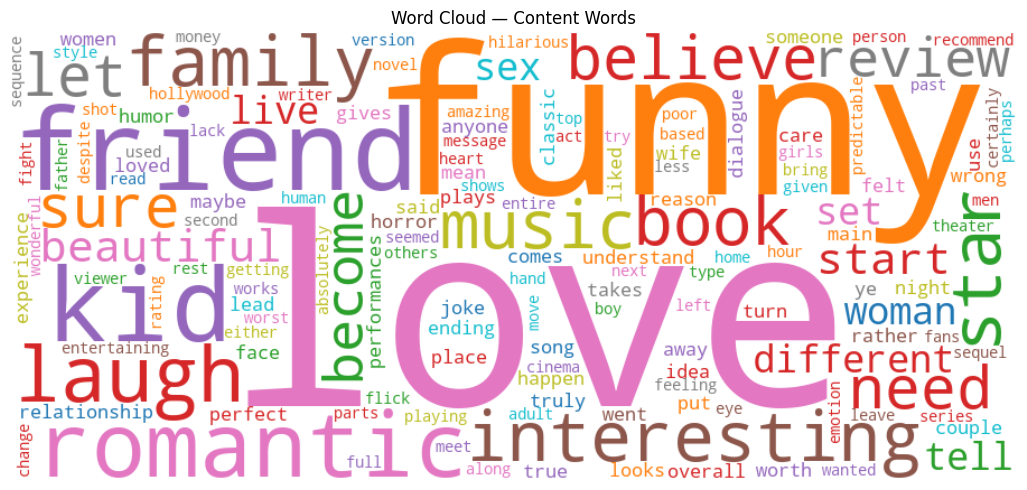

In [27]:
text_for_cloud = ' '.join(flat_content)

wc = WordCloud(width=900, height=400, background_color='white',
               max_words=150, colormap='tab10').generate(text_for_cloud)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Content Words')
plt.tight_layout()
plt.show()

In [28]:
df['primary_genre'] = df['clean_genre'].apply(lambda x: x.split(",")[0].strip())

### TOP 20 CONTENT WORDS BY GENRE

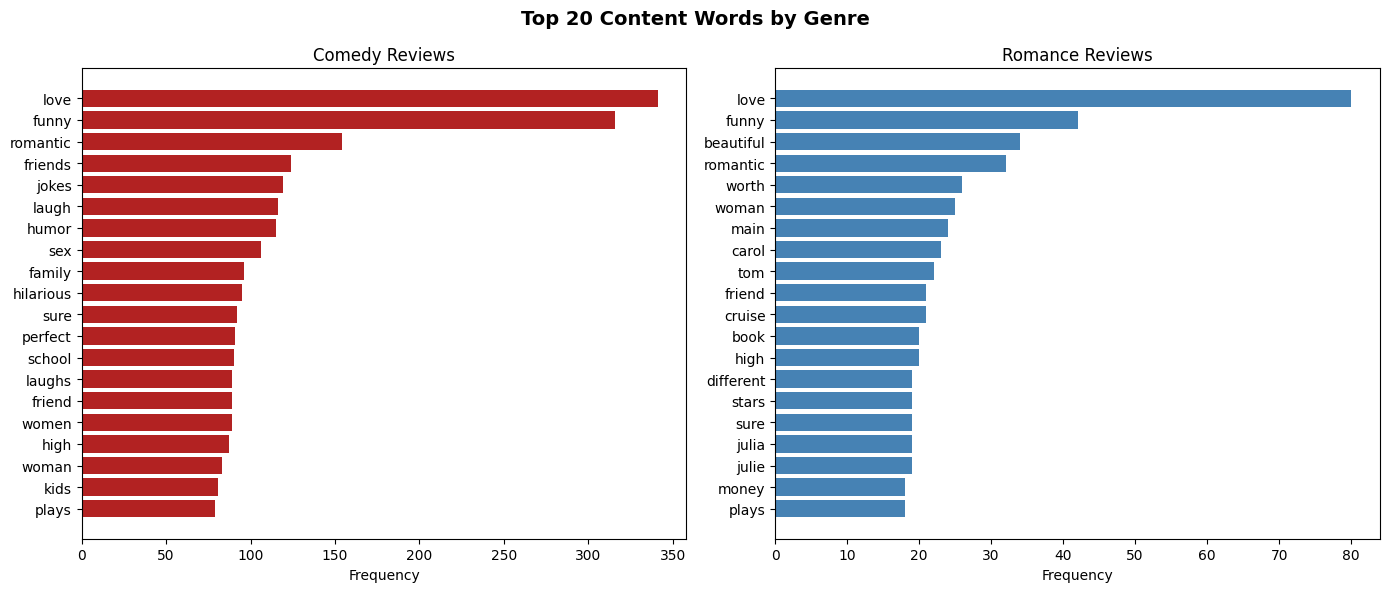

In [29]:
# Top 20 content words by genre

# Separate texts by genre
comedy = []
romance  = []

for i in range(len(reviews)):
    category = str(df['primary_genre'].iloc[i]).lower()
    for word in all_words[i]:
        if word not in STOP_WORDS:
            if category == "comedy":
                comedy.append(word)
            elif category == "romance":
                romance.append(word)

from collections import Counter
import matplotlib.pyplot as plt

# Get top 20 words
top_comedy = Counter(comedy).most_common(20)
top_romance = Counter(romance).most_common(20)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# comedy
words_h, counts_h = zip(*top_comedy)

axes[0].barh(
    list(reversed(words_h)),
    list(reversed(counts_h)),
    color='firebrick'
)

axes[0].set_title('Comedy Reviews')
axes[0].set_xlabel('Frequency')

# romance
words_l, counts_l = zip(*top_romance)

axes[1].barh(
    list(reversed(words_l)),
    list(reversed(counts_l)),
    color='steelblue'
)

axes[1].set_title('Romance Reviews')
axes[1].set_xlabel('Frequency')

plt.suptitle(
    'Top 20 Content Words by Genre',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

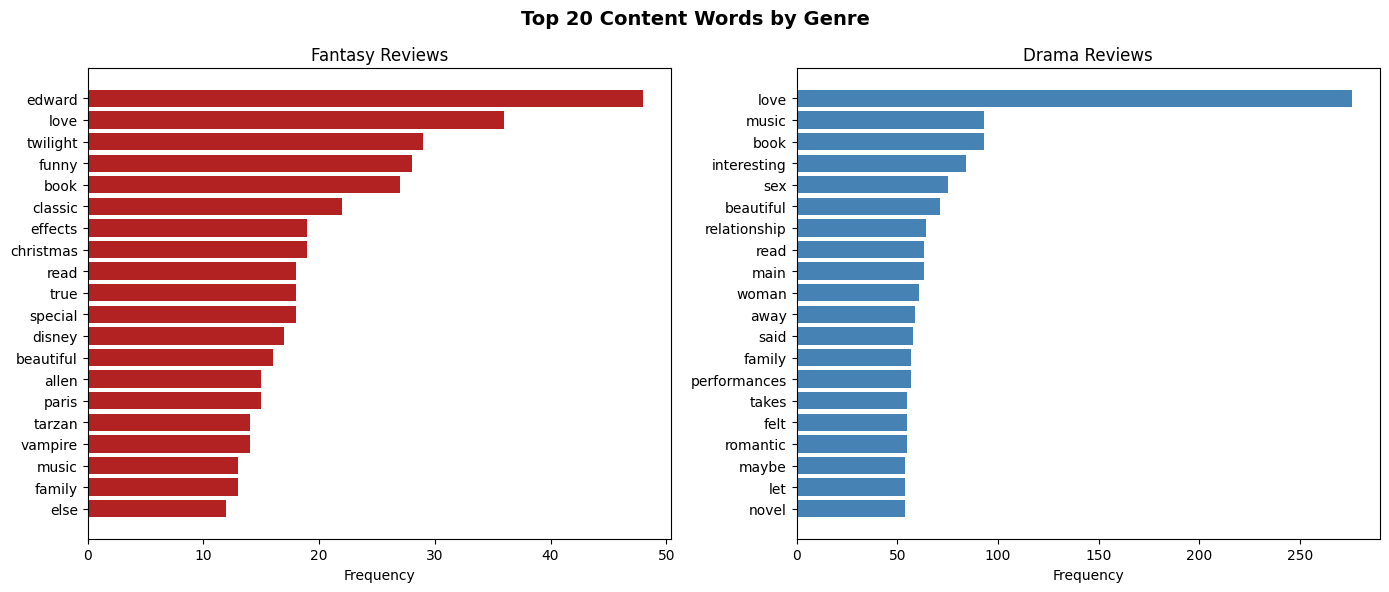

In [30]:
# Top 20 content words by genre, Fantasy and DRAMA

# Separate texts by genre
fantasy = []
drama  = []

for i in range(len(reviews)):
    category = str(df['primary_genre'].iloc[i]).lower()
    for word in all_words[i]:
        if word not in STOP_WORDS:
            if category == "fantasy":
                fantasy.append(word)
            elif category == "drama":
                drama.append(word)

from collections import Counter
import matplotlib.pyplot as plt

# Get top 20 words
top_fantasy = Counter(fantasy).most_common(20)
top_drama = Counter(drama).most_common(20)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# High-price listings
words_h, counts_h = zip(*top_fantasy)

axes[0].barh(
    list(reversed(words_h)),
    list(reversed(counts_h)),
    color='firebrick'
)

axes[0].set_title('Fantasy Reviews')
axes[0].set_xlabel('Frequency')

# Low-price listings
words_l, counts_l = zip(*top_drama)

axes[1].barh(
    list(reversed(words_l)),
    list(reversed(counts_l)),
    color='steelblue'
)

axes[1].set_title('Drama Reviews')
axes[1].set_xlabel('Frequency')

plt.suptitle(
    'Top 20 Content Words by Genre',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [31]:
df.primary_genre.value_counts()

primary_genre
comedy             628
drama              430
action             200
romance            136
adventure          105
horror             105
fantasy             87
thriller            72
family              53
animation           48
crime               47
science fiction     36
mystery             23
music               17
history              4
western              4
tv movie             3
documentary          2
Name: count, dtype: int64

### WORD CLOUDS BY GENRE - COMEDY - ROMANCE

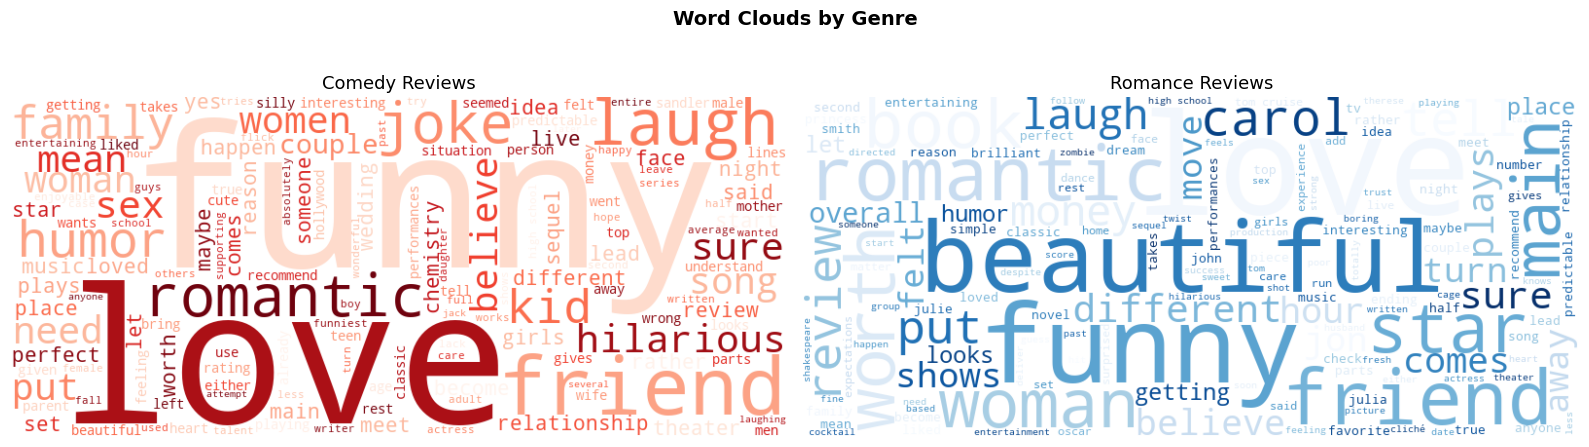

In [32]:
# Build word clouds by genre 
wc_comedy = WordCloud(width=800, height=350, background_color='white', max_words=150, colormap='Reds').generate(' '.join(comedy))

wc_romance = WordCloud(width=800, height=350, background_color='white',
                       max_words=150, colormap='Blues').generate(' '.join(romance))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_comedy, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Comedy Reviews', fontsize=13)

axes[1].imshow(wc_romance, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Romance Reviews', fontsize=13)

plt.suptitle('Word Clouds by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### WORD CLOUDS COMEDY VS DRAMA

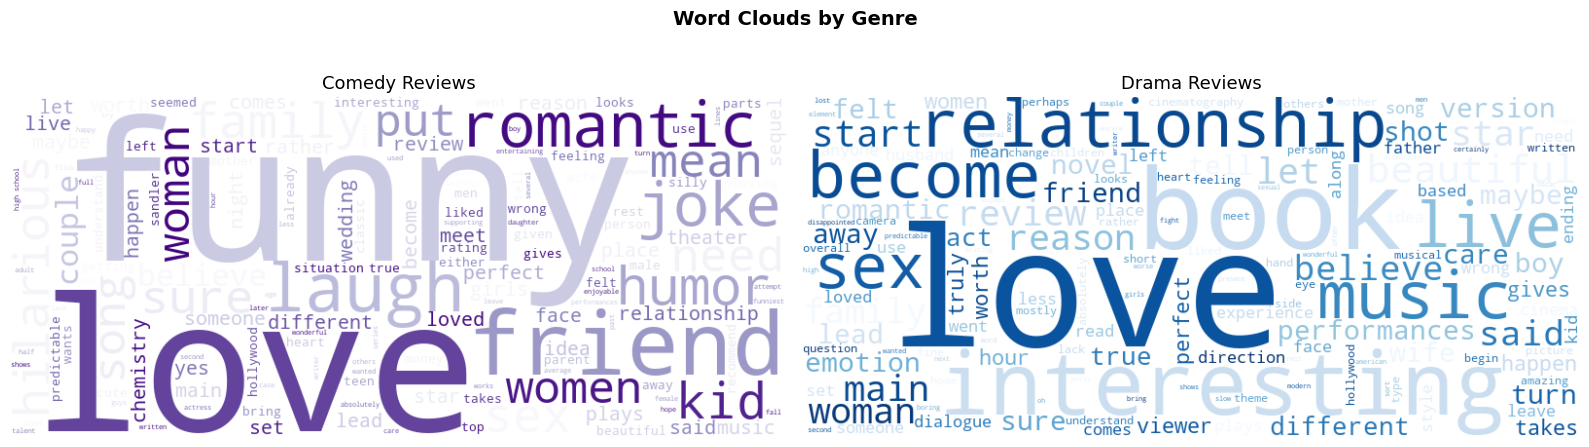

In [33]:
# Build word clouds - comedy - drama
wc_comedy = WordCloud(width=800, height=350, background_color='white', max_words=150, colormap='Purples').generate(' '.join(comedy))

wc_drama = WordCloud(width=800, height=350, background_color='white',max_words=150, colormap='Blues').generate(' '.join(drama))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_comedy, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Comedy Reviews', fontsize=13)

axes[1].imshow(wc_drama, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Drama Reviews', fontsize=13)

plt.suptitle('Word Clouds by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### CONTENT WORDS - HORROR vs ACTION

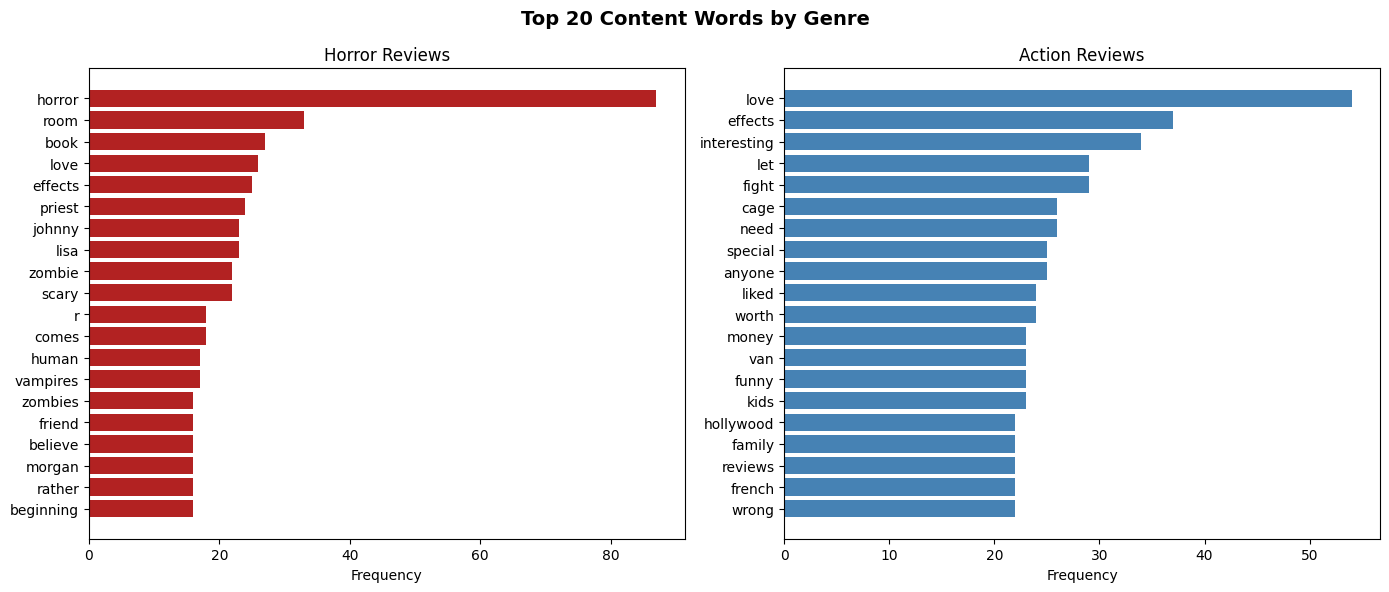

In [34]:
# Top 20 content words by genre, Horror  and ACtion

# Separate texts by genre
horror = []
action  = []

for i in range(len(reviews)):
    category = str(df['primary_genre'].iloc[i]).lower()
    for word in all_words[i]:
        if word not in STOP_WORDS:
            if "horror" in category:
                horror.append(word)
            elif "action" in category:
                action.append(word)

from collections import Counter
import matplotlib.pyplot as plt

# Get top 20 words
top_horror = Counter(horror).most_common(20)
top_action = Counter(action).most_common(20)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# High-price listings
words_h, counts_h = zip(*top_horror)

axes[0].barh(
    list(reversed(words_h)),
    list(reversed(counts_h)),
    color='firebrick'
)

axes[0].set_title('Horror Reviews')
axes[0].set_xlabel('Frequency')

# Low-price listings
words_l, counts_l = zip(*top_action)

axes[1].barh(
    list(reversed(words_l)),
    list(reversed(counts_l)),
    color='steelblue'
)

axes[1].set_title('Action Reviews')
axes[1].set_xlabel('Frequency')

plt.suptitle(
    'Top 20 Content Words by Genre',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### WORD CLOUDS - HORROR vs ACTION

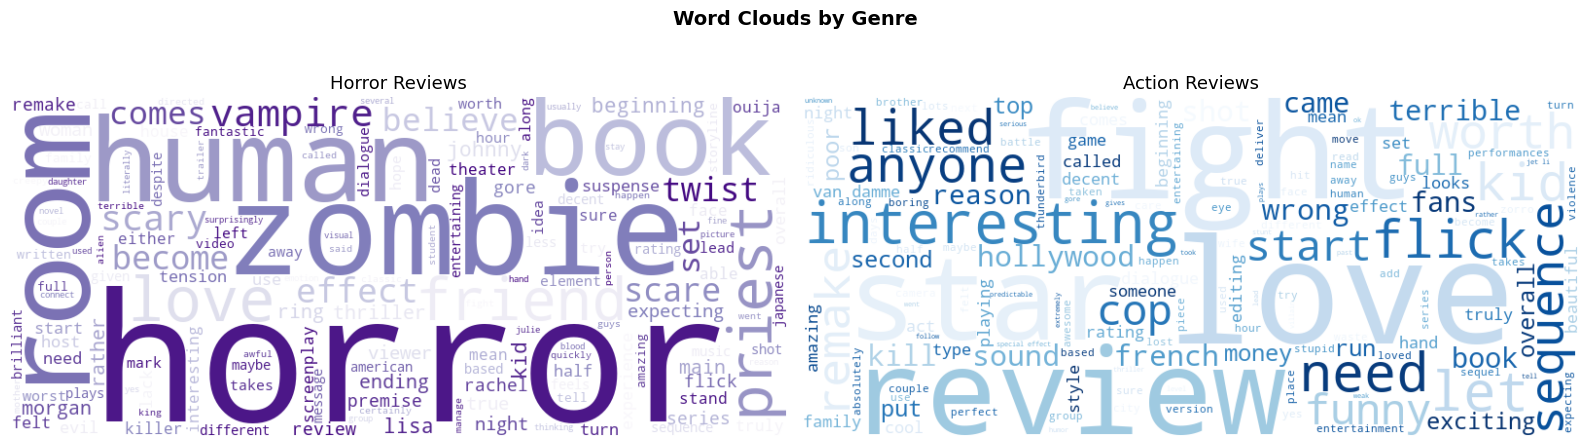

In [35]:
# Build word clouds - horror - action
wc_horror = WordCloud(width=800, height=350, background_color='white', max_words=150, colormap='Purples').generate(' '.join(horror))

wc_action = WordCloud(width=800, height=350, background_color='white',max_words=150, colormap='Blues').generate(' '.join(action))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_horror, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Horror Reviews', fontsize=13)

axes[1].imshow(wc_action, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Action Reviews', fontsize=13)

plt.suptitle('Word Clouds by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Phrase Analysis

### Extract Bigrams

In [36]:
bigram_counter = Counter()

for word_list in all_words:
    # Remove stopwords
    content_words = []
    for word in word_list:
        if word not in STOP_WORDS:
            content_words.append(word)
    # Build bigrams: each consecutive pair
    for i in range(len(content_words) - 1):
        bigram = (content_words[i], content_words[i+1])
        bigram_counter[bigram] += 1

top_bigrams = bigram_counter.most_common(20)
print("Top 20 bigrams:")
for bg, count in top_bigrams:
    print(f"  {' '.join(bg):<30} {count}")

Top 20 bigrams:
  high school                    85
  special effects                75
  fall love                      49
  read book                      46
  box office                     34
  eddie murphy                   32
  adam sandler                   30
  van damme                      30
  cameron diaz                   28
  ben stiller                    28
  gon na                         28
  chick flick                    28
  recommend anyone               26
  pleasantly surprised           26
  laugh loud                     26
  highly recommend               26
  half hour                      25
  someone else                   24
  love interest                  24
  subject matter                 24


### TRIGRAMS

In [37]:
trigram_counter = Counter()

for word_list in all_words:
    content_words = []
    for word in word_list:
        if word not in STOP_WORDS:
            content_words.append(word)
    # Build trigrams: each consecutive triple
    for i in range(len(content_words) - 2):
        trigram = (content_words[i], content_words[i+1], content_words[i+2])
        trigram_counter[trigram] += 1

top_trigrams = trigram_counter.most_common(20)
print("Top 20 trigrams:")
for tg, count in top_trigrams:
    print(f"  {' '.join(tg):<40} {count}")

Top 20 trigrams:
  robert de niro                           11
  secret walter mitty                      10
  jamie lee curtis                         10
  tommy lee jones                          9
  sweet home alabama                       9
  tiger hidden dragon                      9
  crouching tiger hidden                   8
  raise red lantern                        8
  agent cody banks                         7
  jean claude van                          7
  curious case benjamin                    6
  case benjamin button                     6
  harry met sally                          6
  love beth cooper                         6
  red riding hood                          6
  claude van damme                         5
  return blue lagoon                       5
  tour de force                            5
  rio de janeiro                           5
  flintstones viva rock                    5


### TOP 20 BIGRAMS & TRIGRAMS

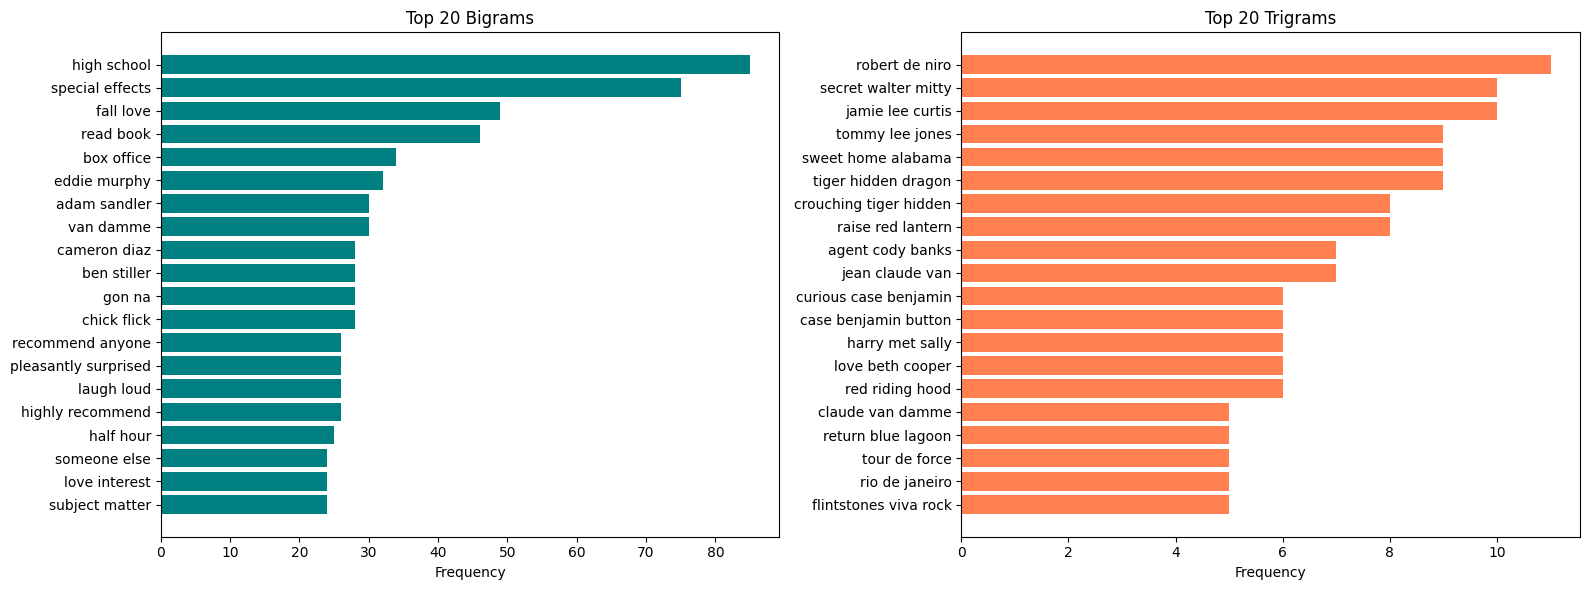

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bigrams
bg_labels = [' '.join(bg) for bg, _ in top_bigrams]
bg_counts  = [c for _, c in top_bigrams]
axes[0].barh(list(reversed(bg_labels)), list(reversed(bg_counts)), color='teal')
axes[0].set_title('Top 20 Bigrams')
axes[0].set_xlabel('Frequency')

# Trigrams
tg_labels = [' '.join(tg) for tg, _ in top_trigrams]
tg_counts  = [c for _, c in top_trigrams]
axes[1].barh(list(reversed(tg_labels)), list(reversed(tg_counts)), color='coral')
axes[1].set_title('Top 20 Trigrams')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### WORD FREQUENCIES BETWEEN HORROR AND COMEDY

In [39]:
# Compare word frequencies between horror and comedy reviews

from collections import Counter
import pandas as pd

high_freq = Counter(top_comedy)
low_freq  = Counter(top_horror)

# Create combined vocabulary
all_terms = set(high_freq.keys()) | set(low_freq.keys())

comparison = []

for term in all_terms:

    high_count = high_freq.get(term, 0)
    low_count  = low_freq.get(term, 0)

    difference = high_count - low_count

    comparison.append([
        term,
        high_count,
        low_count,
        difference
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "word",
        "high_count",
        "low_count",
        "difference"
    ]
)

In [40]:
# Words much more common in comedy reviews than horror reviews

top_high_diff = (
    comparison_df
    .sort_values("difference", ascending=False)
    .head(20)
)

top_high_diff

,word,high_count,low_count,difference
20,"(sure, 92)",1,0,1
15,"(friends, 124)",1,0,1
38,"(kids, 81)",1,0,1
36,"(friend, 89)",1,0,1
34,"(women, 89)",1,0,1
32,"(funny, 316)",1,0,1
30,"(sex, 106)",1,0,1
29,"(woman, 83)",1,0,1
28,"(laughs, 89)",1,0,1
25,"(love, 341)",1,0,1


In [41]:
# Compare word frequencies between horror and comedy reviews

from collections import Counter
import pandas as pd

high_freq = Counter(top_comedy)
low_freq  = Counter(top_horror)

# Create combined vocabulary
all_terms = set(high_freq.keys()) | set(low_freq.keys())

comparison = []

for term in all_terms:

    high_count = high_freq.get(term, 0)
    low_count  = low_freq.get(term, 0)

    difference = high_count - low_count

    comparison.append([
        term,
        high_count,
        low_count,
        difference
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "word",
        "high_count",
        "low_count",
        "difference"
    ]
)

### CONTENT WORDS BY LOW RATING AND HIGH RATING

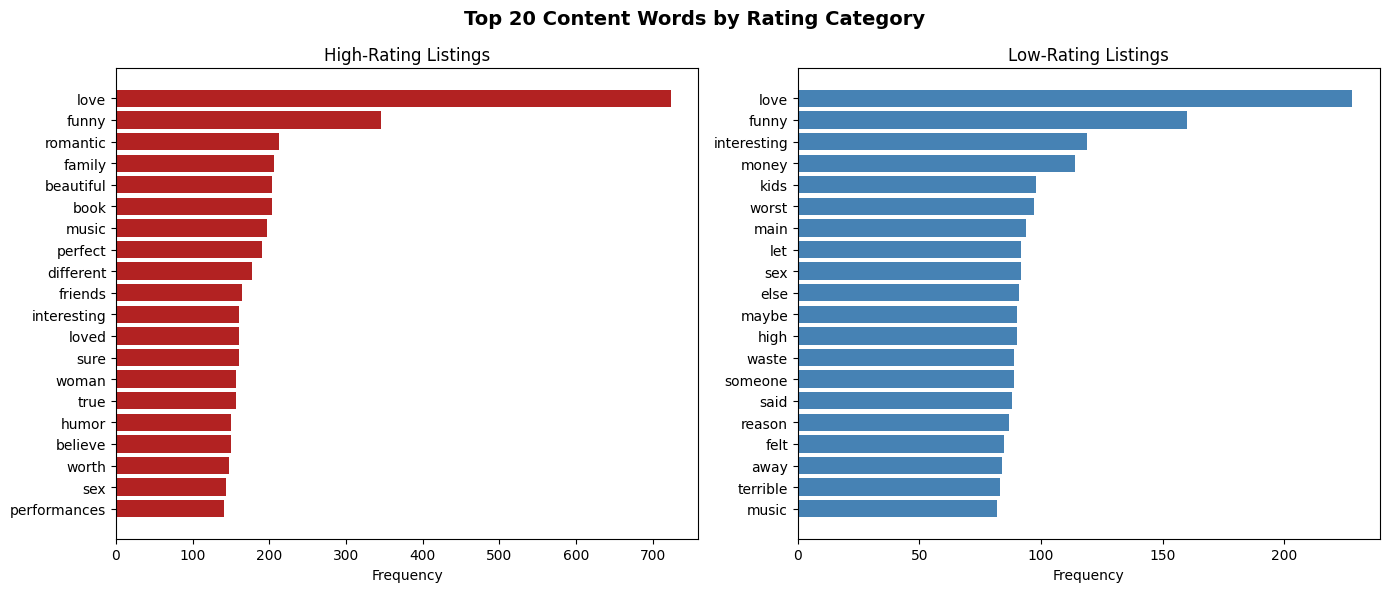

In [42]:
# Top 20 content words by rating

# Separate texts by rating
high_rating_words = []
low_rating_words  = []

for i in range(len(reviews)):
    rating = df['user_rating'].iloc[i]
    for word in all_words[i]:
        if word not in STOP_WORDS:
            if rating > 5: 
                high_rating_words.append(word)
            elif rating <= 5:
                low_rating_words.append(word)

from collections import Counter
import matplotlib.pyplot as plt

# Get top 20 words
top_high = Counter(high_rating_words).most_common(20)
top_low = Counter(low_rating_words).most_common(20)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# High-rating listings
words_h, counts_h = zip(*top_high)

axes[0].barh(
    list(reversed(words_h)),
    list(reversed(counts_h)),
    color='firebrick'
)

axes[0].set_title('High-Rating Listings')
axes[0].set_xlabel('Frequency')

# Low-rating listings
words_l, counts_l = zip(*top_low)

axes[1].barh(
    list(reversed(words_l)),
    list(reversed(counts_l)),
    color='steelblue'
)

axes[1].set_title('Low-Rating Listings')
axes[1].set_xlabel('Frequency')

plt.suptitle(
    'Top 20 Content Words by Rating Category',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [43]:
SAMPLE_N     = 300
sample_reviews = reviews[:SAMPLE_N]

pos_counter      = Counter()
ner_counter      = Counter()
ner_type_counter = Counter()
ner_high         = Counter()   # named entities for high rating reviews
ner_low          = Counter()   # named entities for low rating reviews

for i, doc in enumerate(nlp.pipe(sample_reviews, batch_size=50, disable=['parser'])):
    rating = df['user_rating'].iloc[i]
    # POS tags
    for token in doc:
        if token.is_alpha:
            pos_counter[token.pos_] += 1
    # Named entities
    for ent in doc.ents:
        entity = ent.text.lower()
        ner_counter[entity] += 1
        ner_type_counter[ent.label_] += 1
        # Split by rating category
        if entity.isalpha() or ' ' in entity:
            if rating > 5 :
                ner_high[entity] += 1
            elif rating <= 5 :
                ner_low[entity] += 1

print(f"Finished processing {SAMPLE_N} documents.")
print(f"POS types found    : {len(pos_counter)}")
print(f"Entity types found : {len(ner_type_counter)}")
print(f"High rating entities: {len(ner_high)}")
print(f"Low rating entities : {len(ner_low)}")

Finished processing 300 documents.
POS types found    : 16
Entity types found : 17
High rating entities: 815
Low rating entities : 422


### NAMED ENTITIES BY RATING

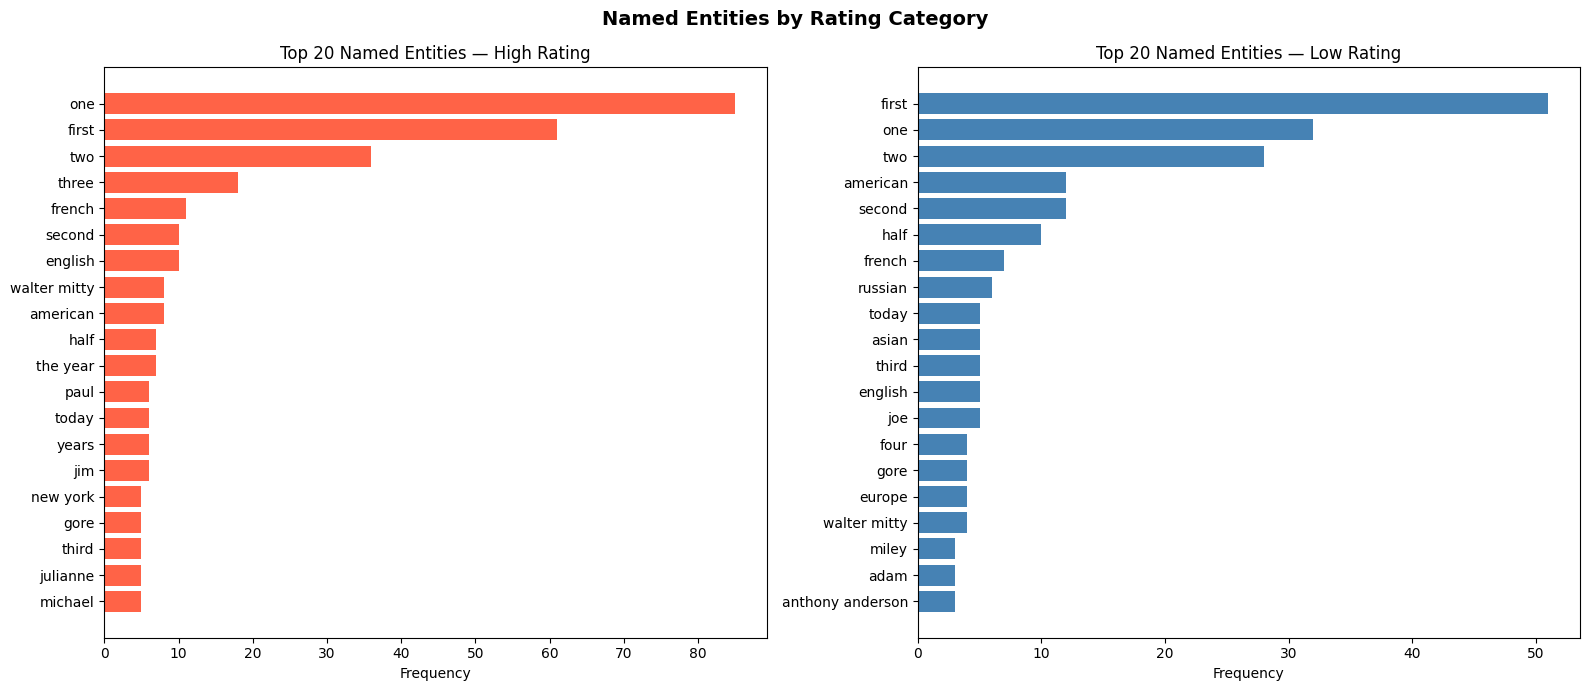

In [44]:
# Build top 20 lists for each rating category
top_ents_high = ner_high.most_common(20)
top_ents_low  = ner_low.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# High rating chart
high_names  = [e for e, _ in top_ents_high]
high_counts = [c for _, c in top_ents_high]
axes[0].barh(list(reversed(high_names)), list(reversed(high_counts)), color='tomato')
axes[0].set_title('Top 20 Named Entities — High Rating')
axes[0].set_xlabel('Frequency')

# Low rating chart
low_names  = [e for e, _ in top_ents_low]
low_counts = [c for _, c in top_ents_low]
axes[1].barh(list(reversed(low_names)), list(reversed(low_counts)), color='steelblue')
axes[1].set_title('Top 20 Named Entities — Low Rating')
axes[1].set_xlabel('Frequency')

plt.suptitle('Named Entities by Rating Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
df['primary_genre'] = df['clean_genre'].apply(lambda x: x.split(",")[0].strip())

### NLTK & SpaCy

### Stemming with NLTK

In [67]:
from nltk.stem.porter import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

porter   = PorterStemmer()
snowball = SnowballStemmer("english")

# Use top 20 content words from corpus (flat_content built in Section 4b)
top_words = [word for word, count in freq_content.most_common(20)]

print(f"{'Original':<20} {'Porter':<20} {'Snowball':<20}")
print("-" * 60)
for word in top_words:
    print(f"{word:<20} {porter.stem(word):<20} {snowball.stem(word):<20}")

Original             Porter               Snowball            
------------------------------------------------------------
love                 love                 love                
funny                funni                funni               
family               famili               famili              
book                 book                 book                
romantic             romant               romant              
interesting          interest             interest            
music                music                music               
beautiful            beauti               beauti              
sure                 sure                 sure                
sex                  sex                  sex                 
kids                 kid                  kid                 
believe              believ               believ              
different            differ               differ              
worth                worth                worth          

### Lemmatization with NLTK

In [68]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

print(f"{'Original':<20} {'Lemma (noun)':<20} {'Lemma (verb)':<20}")
print("-" * 60)
for word in top_words:
    print(f"{word:<20} {lemmatizer.lemmatize(word):<20} {lemmatizer.lemmatize(word, pos='v'):<20}")

Original             Lemma (noun)         Lemma (verb)        
------------------------------------------------------------
love                 love                 love                
funny                funny                funny               
family               family               family              
book                 book                 book                
romantic             romantic             romantic            
interesting          interesting          interest            
music                music                music               
beautiful            beautiful            beautiful           
sure                 sure                 sure                
sex                  sex                  sex                 
kids                 kid                  kid                 
believe              believe              believe             
different            different            different           
worth                worth                worth          

### Noun Chunks

In [70]:
from collections import Counter

chunk_counter = Counter()

for doc in nlp.pipe(reviews, batch_size=50):
    for chunk in doc.noun_chunks:
        chunk_text = chunk.text.lower().strip()
        if len(chunk_text.split()) > 1:   # only multi-word chunks
            chunk_counter[chunk_text] += 1

top_chunks = chunk_counter.most_common(20)

print("Top 20 noun chunks across all listings:")
for chunk, count in top_chunks:
    print(f"  {chunk:<40} {count}")

Top 20 noun chunks across all listings:
  this movie                               1459
  the movie                                1203
  the film                                 1130
  this film                                865
  the story                                500
  a movie                                  322
  a lot                                    304
  the end                                  260
  the characters                           260
  a film                                   232
  the plot                                 202
  the book                                 178
  the audience                             156
  this one                                 154
  the way                                  143
  the cast                                 132
  the acting                               131
  the script                               130
  the rest                                 127
  the world                                124


### ASPECT WORDS WITHIN GENRES HORROR and DRAMA

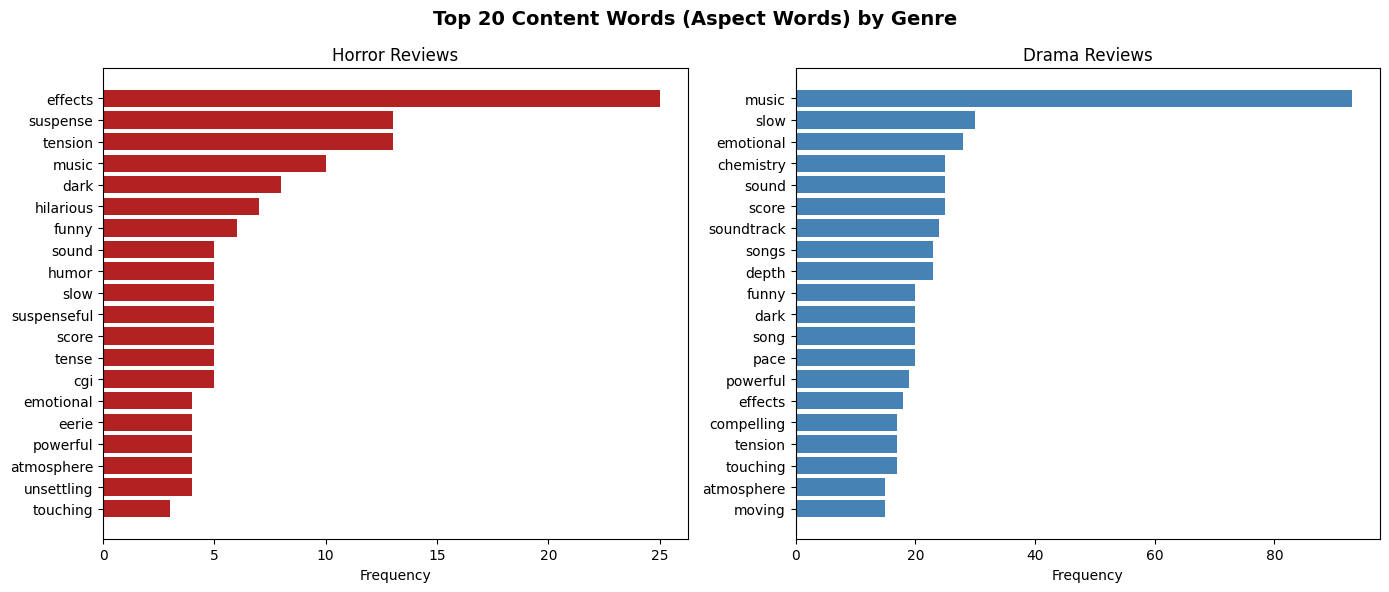

In [48]:
# Top 20 content words by aspect words within genre, HORROR and DRAMA

# Separate texts by genre
horror_aspect = []
drama_aspect = []

for i in range(len(reviews)):
    category = str(df['primary_genre'].iloc[i]).lower()
    for word in all_words[i]:
        if word in aspect_words:
                if category == "horror":
                  horror_aspect.append(word)
                elif category == "drama":
                  drama_aspect.append(word)

from collections import Counter
import matplotlib.pyplot as plt

# Get top 20 words
top_horror = Counter(horror_aspect).most_common(20)
top_drama = Counter(drama_aspect).most_common(20)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# High-price listings
words_h, counts_h = zip(*top_horror)

axes[0].barh(
    list(reversed(words_h)),
    list(reversed(counts_h)),
    color='firebrick'
)

axes[0].set_title('Horror Reviews')
axes[0].set_xlabel('Frequency')

# Low-price listings
words_l, counts_l = zip(*top_drama)

axes[1].barh(
    list(reversed(words_l)),
    list(reversed(counts_l)),
    color='steelblue'
)

axes[1].set_title('Drama Reviews')
axes[1].set_xlabel('Frequency')

plt.suptitle(
    'Top 20 Content Words (Aspect Words) by Genre',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

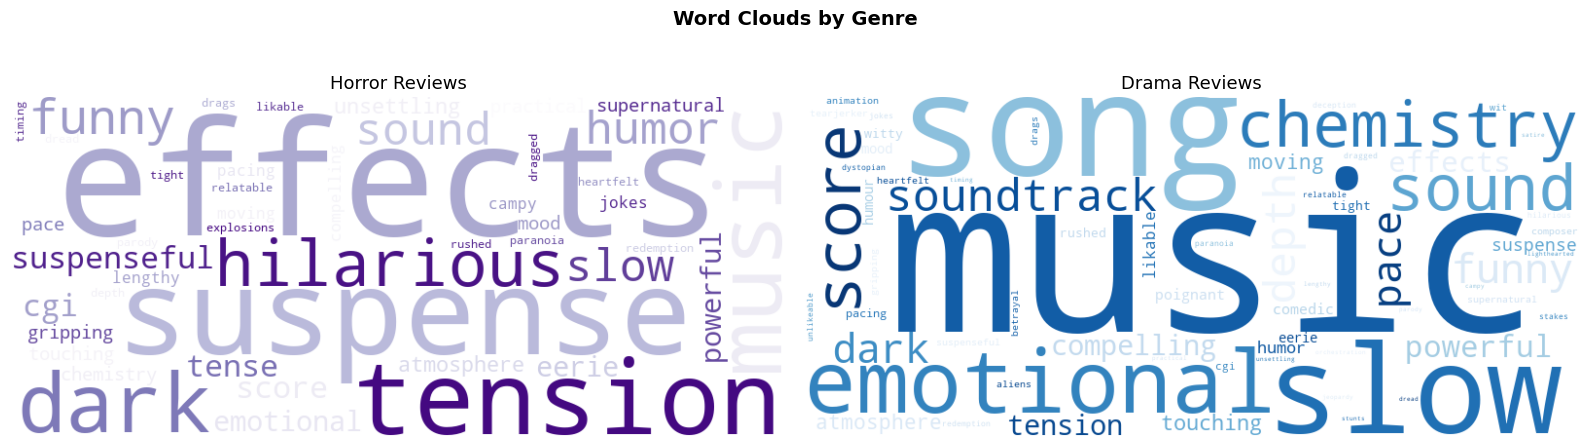

In [49]:
# Build word clouds - horror - action
wc_horror = WordCloud(width=800, height=350, background_color='white', max_words=150, colormap='Purples').generate(' '.join(horror_aspect))

wc_drama= WordCloud(width=800, height=350, background_color='white',max_words=150, colormap='Blues').generate(' '.join(drama_aspect))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_horror, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Horror Reviews', fontsize=13)

axes[1].imshow(wc_drama, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Drama Reviews', fontsize=13)

plt.suptitle('Word Clouds by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

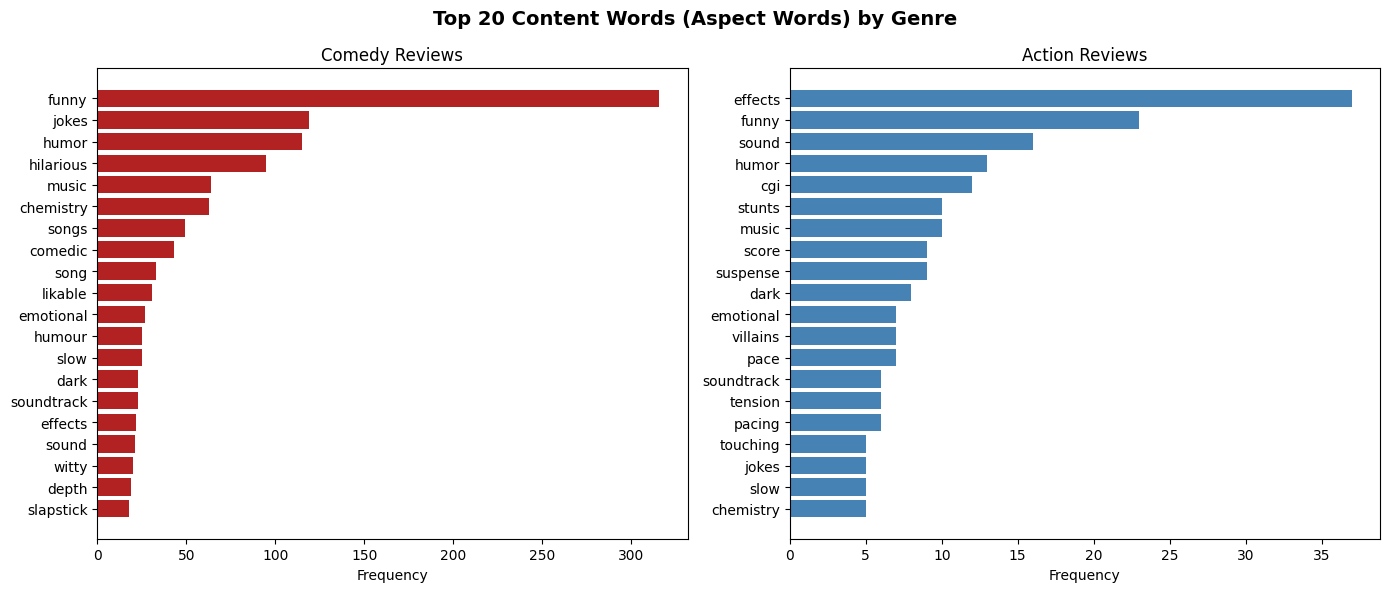

In [50]:
# Top 20 content words by aspect words within genre, COMEDY and ACTION

# Separate texts by genre
comedy_aspect  = []
action_aspect = []

for i in range(len(reviews)):
    category = str(df['primary_genre'].iloc[i]).lower()
    for word in all_words[i]:
        if word in aspect_words:
                if category == "comedy":
                  comedy_aspect.append(word)
                elif category == "action":
                  action_aspect.append(word)

from collections import Counter
import matplotlib.pyplot as plt

# Get top 20 words
top_comedy = Counter(comedy_aspect).most_common(20)
top_action = Counter(action_aspect).most_common(20)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# High-price listings
words_h, counts_h = zip(*top_comedy)

axes[0].barh(
    list(reversed(words_h)),
    list(reversed(counts_h)),
    color='firebrick'
)

axes[0].set_title('Comedy Reviews')
axes[0].set_xlabel('Frequency')

# Low-price listings
words_l, counts_l = zip(*top_action)

axes[1].barh(
    list(reversed(words_l)),
    list(reversed(counts_l)),
    color='steelblue'
)

axes[1].set_title('Action Reviews')
axes[1].set_xlabel('Frequency')

plt.suptitle(
    'Top 20 Content Words (Aspect Words) by Genre',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
print('✅ Libraries loaded')

✅ Libraries loaded


In [54]:
df.head(5)

,clean_movie_name,movie_name,movie_name_metadata,user_rating,movie_score,emotion,clean_reviews,clean_genre,clean_overview,clean_description,...,tfidf_scenes,tfidf_see,tfidf_story,tfidf_think,tfidf_time,tfidf_two,tfidf_watch,tfidf_way,tfidf_well,primary_genre
0,the dictator,The Dictator,The Dictator,10.0,62.0,sadness,i wish there were more comedies like that - cr...,comedy,the heroic story of a dictator who risks his l...,"pursued by a cab driver for an unpaid fare, a ...",...,0.0,0.206251,0.000000,0.0,0.000000,0.0,0.253051,0.000000,0.211851,comedy
1,the assignment,The Assignment,The Assignment,3.0,55.0,anticipation,for a film that is strangely underwhelming and...,"action, crime, thriller",ace assassin frank kitchen is double crossed b...,obie (erica marks) is second-in-command in the...,...,0.0,0.000000,0.134083,0.0,0.139404,0.0,0.000000,0.000000,0.000000,action
2,big game,Big Game,Big Game,3.0,55.0,joy,comic book violence with gleaming visuals apar...,"action, adventure, thriller","air force one is shot down by terrorists, leav...","larry winthrop, the pampered son of an aristoc...",...,0.0,0.000000,0.000000,0.0,0.213408,0.0,0.000000,0.000000,0.214268,action
3,sixteen candles,Sixteen Candles,Sixteen Candles,7.0,68.0,sadness,"movies in the 80's were really cool, nice stor...","comedy, romance",a teenage girl deals with her parents forgetti...,"a girl's ""sweet"" sixteenth birthday is anythin...",...,0.0,0.000000,0.078997,0.0,0.082132,0.0,0.000000,0.095145,0.000000,comedy
4,the sorcerer's apprentice,The Sorcerer's Apprentice,The Sorcerer's Apprentice,8.0,61.0,fear,jay b. is funny and charming in a believably n...,"fantasy, adventure, action",balthazar blake is a master sorcerer in modern...,a young boy becomes an apprentice for a myster...,...,0.0,0.181887,0.178973,0.0,0.000000,0.0,0.000000,0.000000,0.186826,fantasy


In [55]:
df["clean_genre"]

0                                           comedy
1                          action, crime, thriller
2                      action, adventure, thriller
3                                  comedy, romance
4                       fantasy, adventure, action
                           ...                    
1995                               romance, comedy
1996    fantasy, drama, thriller, mystery, romance
1997    action, adventure, history, romance, drama
1998                 comedy, music, romance, drama
1999                              thriller, horror
Name: clean_genre, Length: 2000, dtype: object

### TF-IDF

In [56]:
comedy_mask = df['primary_genre'].apply(lambda genre_list: "comedy" in genre_list)
comedy_df = df.loc[comedy_mask]

tfidf_vectorizer = TfidfVectorizer(
    stop_words=list(STOP_WORDS),
    lowercase=True,
    min_df=1,
    max_df=.5
)

tfidf_matrix = tfidf_vectorizer.fit_transform(comedy_df['clean_reviews'])
tfidf_vocab  = tfidf_vectorizer.get_feature_names_out()

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

TF-IDF matrix shape: (628, 12141)


In [57]:
# ── Our running example listing ──────────────────────────────
Movie_Review = 3  # Movie Reviews comedy example
example = comedy_df.loc[3]

print('=' * 65)
print('Movie Review ')
print('=' * 65)
print(f"Movie Name        : {example['movie_name']}")
print(f"Review: {example['clean_reviews']}")
print(f"Genre      : {example['primary_genre']}")
print(f"Description : {example['clean_description']}")
print('=' * 65)

Movie Review 
Movie Name        : Sixteen Candles
Review: movies in the 80's were really cool, nice story lines, very real people and cute guys too! 80's movies were so musical, full of dance and laughter, really good acting and good use of props. i wish movies were like the old classic movies, movies nowadays are somewhat a rip off, i'm not saying all but most movies made in this era are all computerized, there's so much plastic surgery happening, drastic diets, if you look back at the old movies, the ladies are really beautiful naturally, nice hair, and the spark in those eyes, men were romantic. i watched sixteen candles for the first time, and i enjoyed it. i liked pretty in pink better though. sixteen candles is a really funny yet in a sweet romantic sort of way....the geeks and the duck guy, hilarious! i enjoy watching classic movies, eg. dirty dancing, ghost, gremlin, pretty in pink, ghost busters.... i wouldn't recommend this movie to kids 14+, especially if you don't like watc

In [58]:
# TF-IDF scores for the running example
example_tfidf = tfidf_matrix[Movie_Review].toarray().flatten()
tfidf_df = pd.DataFrame({'word': tfidf_vocab, 'tfidf': example_tfidf})
tfidf_df = tfidf_df[tfidf_df['tfidf'] > 0].sort_values('tfidf', ascending=False)

print('TF-IDF scores for comedy Review (top words):')
print(tfidf_df.head(12).to_string(index=False))


TF-IDF scores for comedy Review (top words):
      word    tfidf
     parts 0.297874
   someone 0.288188
  revolved 0.283048
dramatized 0.253986
 connected 0.244630
frustrated 0.244630
     super 0.230523
     punch 0.219986
      yeah 0.204569
   genuine 0.198569
    cliché 0.186507
    single 0.180648


In [59]:
# IDF values — see which words are rarest in the corpus
idf_df = pd.DataFrame({'word': tfidf_vocab, 'idf': tfidf_vectorizer.idf_})
print('10 HIGHEST IDF words (rarest across the corpus):')
print(idf_df.sort_values('idf', ascending=False).head(10).to_string(index=False))
print('\n10 LOWEST IDF words (most common across the corpus):')
print(idf_df.sort_values('idf').head(10).to_string(index=False))

10 HIGHEST IDF words (rarest across the corpus):
        word      idf
          00 6.750984
      metres 6.750984
   minefield 6.750984
mindlessness 6.750984
  mindlessly 6.750984
mindboggling 6.750984
       minaj 6.750984
      milton 6.750984
       milos 6.750984
       milla 6.750984

10 LOWEST IDF words (most common across the corpus):
     word      idf
    funny 2.032485
     love 2.150826
 romantic 2.799740
    laugh 2.809402
       10 2.829011
    jokes 2.966794
    humor 3.049682
hilarious 3.062105
  friends 3.062105
     sure 3.074683


In [63]:
pip install gensim

  Using cached gensim-4.4.0-cp310-cp310-macosx_11_0_arm64.whl (24.4 MB)
You should consider upgrading via the '/Users/alexandraflores/venv/bin/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [64]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# Tokenize all descriptions
tokenized_corpus = [simple_preprocess(doc) for doc in df['clean_reviews']]

print('Tokenized running example:')
print(tokenized_corpus[Movie_Review])

Tokenized running example:
['movies', 'in', 'the', 'were', 'really', 'cool', 'nice', 'story', 'lines', 'very', 'real', 'people', 'and', 'cute', 'guys', 'too', 'movies', 'were', 'so', 'musical', 'full', 'of', 'dance', 'and', 'laughter', 'really', 'good', 'acting', 'and', 'good', 'use', 'of', 'props', 'wish', 'movies', 'were', 'like', 'the', 'old', 'classic', 'movies', 'movies', 'nowadays', 'are', 'somewhat', 'rip', 'off', 'not', 'saying', 'all', 'but', 'most', 'movies', 'made', 'in', 'this', 'era', 'are', 'all', 'computerized', 'there', 'so', 'much', 'plastic', 'surgery', 'happening', 'drastic', 'diets', 'if', 'you', 'look', 'back', 'at', 'the', 'old', 'movies', 'the', 'ladies', 'are', 'really', 'beautiful', 'naturally', 'nice', 'hair', 'and', 'the', 'spark', 'in', 'those', 'eyes', 'men', 'were', 'romantic', 'watched', 'sixteen', 'candles', 'for', 'the', 'first', 'time', 'and', 'enjoyed', 'it', 'liked', 'pretty', 'in', 'pink', 'better', 'though', 'sixteen', 'candles', 'is', 'really', 'f

In [65]:
# Train Word2Vec on our corpus
# NOTE: In practice you'd train on a much larger corpus.
# Here we use vector_size=50 because our corpus is tiny.
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=300,    # 50 dimensions (use 100-300 on a real dataset)
    window=3,          # context window size
    min_count=1,       # include all words
    workers=2,
    epochs=100,        # train longer to compensate for tiny corpus
    sg=1               # Skip-gram (sg=0 for CBOW)
)

print(f'Vocabulary size: {len(w2v_model.wv.key_to_index)} words')
print(f'Vector dimensions: {w2v_model.vector_size}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 22858 words
Vector dimensions: 300


In [ ]:
print("comedy" in STOP_WORDS)  # should be False
print(type(custom_stopwords))         # should be list
print(len(custom_stopwords))

### TF-IDF WORD CLOUD COMEDY

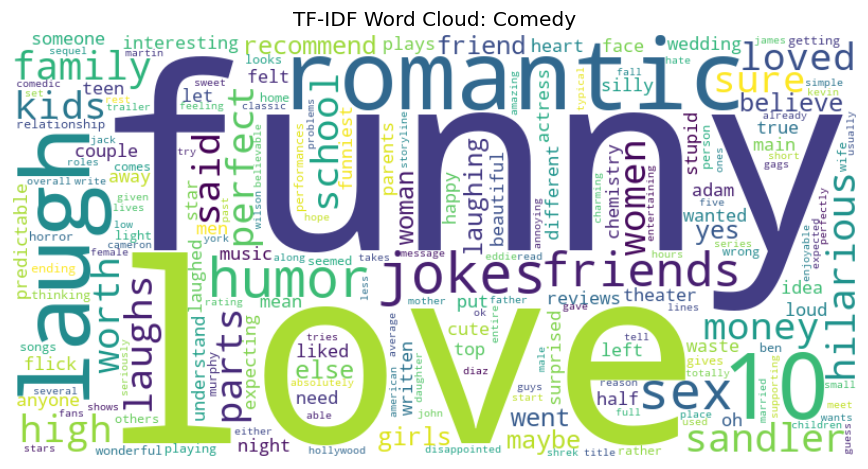

In [66]:
word_scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
word_freq = dict(zip(tfidf_vocab, word_scores))

wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.title("TF-IDF Word Cloud: Comedy")
plt.axis("off")
plt.show()